In [1]:
def gram_to_coxeter_matrix(G):
    """Convert Gram matrix to Coxeter matrix using exact arithmetic."""
    n = G.nrows()
    M = matrix(ZZ, n, n)
    
    for i in range(n):
        M[i,i] = 1
        for j in range(i+1, n):
            if G[i,j] == 0:
                M[i,j] = M[j,i] = 2
            else:
                val = abs(G[i,j])
                if val == 1:
                    M[i,j] = M[j,i] = 3
                elif val == sqrt(2) or val == 2:
                    M[i,j] = M[j,i] = 4
                elif val == sqrt(3) or val == 3:
                    M[i,j] = M[j,i] = 6
                elif val == (1 + sqrt(5))/2:  # Golden ratio
                    M[i,j] = M[j,i] = 5
                elif val > 2:
                    M[i,j] = M[j,i] = -1
                else:
                    try:
                        m = numerical_approx(pi/arccos(val/2))
                        M[i,j] = M[j,i] = round(m) if m >= 2 else -1
                    except:
                        M[i,j] = M[j,i] = -1
    return M

def coxeter_diagram_tikz(G, title="", labels=None):
    """Generate TikZ code for Coxeter diagram from Gram matrix."""
    n = G.nrows()
    M = gram_to_coxeter_matrix(G)
    
    # Default labels
    if labels is None:
        labels = [f"\\alpha_{{{i+1}}}" for i in range(n)]
    
    # Position nodes
    if n <= 4:
        pos = [(2*i, 0) for i in range(n)]
    else:
        angles = [2*pi*i/n for i in range(n)]
        pos = [(3*cos(a), 3*sin(a)) for a in angles]
    
    # Build TikZ code
    tikz = ["\\begin{tikzpicture}[scale=1.2]"]
    tikz.append("\\tikzstyle{vertex}=[circle,draw,minimum size=8mm,inner sep=2pt]")
    
    # Add nodes with colors based on squared norms
    for i in range(n):
        x, y = pos[i]
        norm_sq = abs(G[i,i])
        
        if norm_sq == 2:
            color = "white"
        elif norm_sq == 4:
            color = "blue!20"
        else:
            color = "red!20"
        
        tikz.append(f"\\node[vertex,fill={color}] (n{i}) at ({float(x):.2f},{float(y):.2f}) {{${labels[i]}$}};")
        tikz.append(f"\\node[above=3mm] at (n{i}) {{\\scriptsize $\\|\\alpha_{{{i+1}}}\\|^2={norm_sq}$}};")
    
    # Add edges
    for i in range(n):
        for j in range(i+1, n):
            m = M[i,j]
            if m > 2 or m == -1:
                if m == 3:
                    tikz.append(f"\\draw (n{i}) -- (n{j});")
                elif m == 4:
                    tikz.append(f"\\draw[double,double distance=1.5pt] (n{i}) -- (n{j});")
                elif m == 5:
                    tikz.append(f"\\draw[decorate,decoration={{zigzag,segment length=4mm,amplitude=1mm}}] (n{i}) -- (n{j});")
                elif m == 6:
                    tikz.append(f"\\draw[double,double distance=3pt] (n{i}) -- (n{j});")
                    tikz.append(f"\\draw (n{i}) -- (n{j});")
                elif m == -1:
                    tikz.append(f"\\draw[dashed,thick] (n{i}) -- (n{j});")
                else:
                    tikz.append(f"\\draw (n{i}) -- (n{j}) node[midway,above] {{\\small {m}}};")
    
    # Add title
    if title:
        tikz.append(f"\\node at ({sum(p[0] for p in pos)/n:.2f},2.5) {{\\Large \\textbf{{{title}}}}};")
    
    tikz.append("\\end{tikzpicture}")
    
    return "\n".join(tikz)

def display_tikz_pdf(tikz_code):
    """Compile TikZ to PDF and display."""
    from sage.misc.temporary_file import tmp_filename
    import subprocess
    import os
    
    # Create standalone document
    doc = [
        "\\documentclass[tikz,border=10pt]{standalone}",
        "\\usepackage{tikz}",
        "\\usetikzlibrary{decorations.pathmorphing}",
        "\\begin{document}",
        tikz_code,
        "\\end{document}"
    ]
    
    # Save to temp file
    tex_file = tmp_filename(ext='.tex')
    pdf_file = tex_file.replace('.tex', '.pdf')
    
    with open(tex_file, 'w') as f:
        f.write("\n".join(doc))
    
    # Compile
    result = subprocess.run(['pdflatex', '-interaction=nonstopmode', tex_file], 
                          capture_output=True, cwd=os.path.dirname(tex_file))
    
    if os.path.exists(pdf_file):
        os.system(f'xdg-open {pdf_file} &')
        return pdf_file
    else:
        print("Compilation failed. TikZ code:")
        print(tikz_code)
        return None

def tikz_to_latex_expr(tikz_code):
    """Convert TikZ code to LatexExpr for notebook display."""
    from sage.misc.latex import LatexExpr
    return LatexExpr(tikz_code)

def root_system_gram_matrix(cartan_type):
    """Get Gram matrix from root system."""
    R = RootSystem(cartan_type)
    L = R.root_lattice()
    simple = L.simple_roots()
    
    n = len(simple)
    G = matrix(QQ, n, n)
    
    for i in range(1, n+1):
        for j in range(1, n+1):
            G[i-1,j-1] = L.simple_root(i).scalar(L.simple_root(j))
    
    return G

# Main functions for user interaction
def coxeter_tikz(gram_matrix, title="", display_method="code"):
    """
    Generate and optionally display Coxeter diagram.
    
    display_method: "code" (return TikZ), "pdf" (compile and show), "latex" (return LatexExpr)
    """
    tikz_code = coxeter_diagram_tikz(gram_matrix, title)
    
    if display_method == "code":
        return tikz_code
    elif display_method == "pdf":
        return display_tikz_pdf(tikz_code)
    elif display_method == "latex":
        return tikz_to_latex_expr(tikz_code)
    else:
        return tikz_code

def coxeter_from_type(cartan_type, display_method="code"):
    """Quick Coxeter diagram from Cartan type."""
    G = root_system_gram_matrix(cartan_type)
    title = f"{cartan_type} Coxeter Diagram"
    return coxeter_tikz(G, title, display_method)

# Examples
def show_examples():
    """Display example Coxeter diagrams."""
    examples = {
        'A3': matrix([[-2, 1, 0], [1, -2, 1], [0, 1, -2]]),
        'B3': matrix([[-4, 2, 0], [2, -4, 2], [0, 2, -2]]),
        'G2': matrix([[-2, 3], [3, -6]]),
        'H3': matrix([[-2, (1+sqrt(5))/2, 0], 
                      [(1+sqrt(5))/2, -2, 1], 
                      [0, 1, -2]])
    }
    
    results = {}
    for name, gram in examples.items():
        tikz = coxeter_tikz(gram, f"{name} Coxeter Diagram", "code")
        results[name] = tikz
        print(f"\n{name} TikZ code:")
        print(tikz)
        print("-" * 60)
    
    return results

# Notebook-friendly display
def notebook_coxeter(gram_matrix, title=""):
    """Display in Jupyter notebook."""
    tikz = coxeter_diagram_tikz(gram_matrix, title)
    from IPython.display import display, Latex
    display(Latex(tikz))
    return tikz

In [2]:
def coxeter_order(g):
    """Gram entry to Coxeter order."""
    a = abs(g)
    if g == 0: return 2
    if a == 1: return 3
    if a in [2, sqrt(2)]: return 4
    if a in [3, sqrt(3)]: return 6
    if a > 2: return -1
    return round(pi/arccos(a/2))

def coxeter_tikz(G):
    """Generate TikZ for Coxeter diagram."""
    n = G.nrows()
    tikz = ["\\begin{tikzpicture}"]
    
    # Nodes
    for i in range(n):
        x = 2*i
        tikz.append(f"\\node[circle,draw,fill=white] (n{i}) at ({x},0) {{${i+1}$}};")
    
    # Edges
    for i in range(n):
        for j in range(i+1, n):
            m = coxeter_order(G[i,j])
            if m == 3:
                tikz.append(f"\\draw (n{i}) -- (n{j});")
            elif m == 4:
                tikz.append(f"\\draw[double] (n{i}) -- (n{j});")
            elif m == 6:
                tikz.append(f"\\draw[double,double distance=3pt] (n{i}) -- (n{j});")
                tikz.append(f"\\draw (n{i}) -- (n{j});")
            elif m == -1:
                tikz.append(f"\\draw[dashed] (n{i}) -- (n{j});")
            elif m > 6:
                tikz.append(f"\\draw (n{i}) -- (n{j}) node[midway,above] {{{m}}};")
    
    tikz.append("\\end{tikzpicture}")
    return "\n".join(tikz)

def show_coxeter(G):
    """Display Coxeter diagram in Jupyter."""
    from sage.misc.latex_standalone import TikzPicture
    tikz_code = coxeter_tikz(G)
    return TikzPicture(tikz_code)


A2 Coxeter diagram:


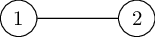


A3 Coxeter diagram:


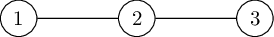


A4 Coxeter diagram:


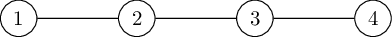


B2 Coxeter diagram:


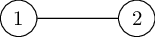


B3 Coxeter diagram:


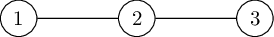


B4 Coxeter diagram:


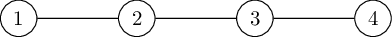


C3 Coxeter diagram:


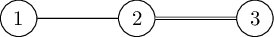


C4 Coxeter diagram:


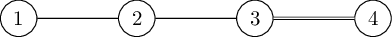


D4 Coxeter diagram:


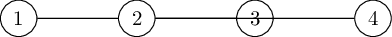


D5 Coxeter diagram:


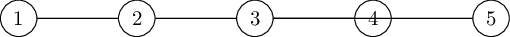


E6 Coxeter diagram:


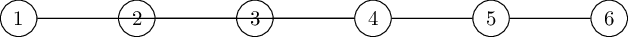


E7 Coxeter diagram:


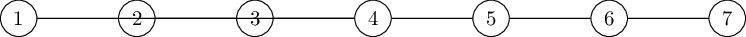


E8 Coxeter diagram:


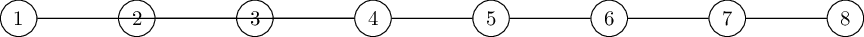


F4 Coxeter diagram:


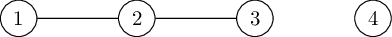


G2 Coxeter diagram:


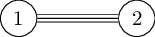



Non-crystallographic types:

H3 Coxeter diagram:


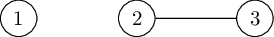


H4 Coxeter diagram:


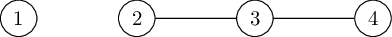


I5 Coxeter diagram:


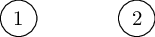

In [3]:
# Sage RootSystem API cheat sheet and corrected implementation

# Key RootSystem methods:
# R = RootSystem(['A', 3])
# R.cartan_type() - returns the Cartan type object
# R.cartan_type().rank() - returns the rank (number of simple roots)
# R.ambient_space() - returns ambient space (if it exists)
# R.weight_space() - returns weight space (always exists)
# R.root_space() - returns root space
# R.root_lattice() - returns root lattice
# 
# For simple roots:
# V.simple_roots() - returns simple roots as a family indexed 1..n
# V.simple_root(i) - returns i-th simple root
#
# For inner products:
# v.inner_product(w) - computes inner product in ambient/weight space
# v.scalar(w) - alternative name for inner product

test_types = [
    ("A2", ['A', 2]),
    ("A3", ['A', 3]),
    ("A4", ['A', 4]),
    ("B2", ['B', 2]),
    ("B3", ['B', 3]),
    ("B4", ['B', 4]),
    ("C3", ['C', 3]),
    ("C4", ['C', 4]),
    ("D4", ['D', 4]),
    ("D5", ['D', 5]),
    ("E6", ['E', 6]),
    ("E7", ['E', 7]),
    ("E8", ['E', 8]),
    ("F4", ['F', 4]),
    ("G2", ['G', 2])
]

for name, cartan_type in test_types:
    print(f"\n{name} Coxeter diagram:")
    try:
        R = RootSystem(cartan_type)
        
        # Get the rank from cartan_type
        n = R.cartan_type().rank()
        
        # Use ambient space if available, otherwise weight space
        if R.ambient_space():
            V = R.ambient_space()
        else:
            V = R.weight_space()
        
        simple = V.simple_roots()
        
        # Build Gram matrix
        G = matrix(QQ, n, n)
        for i in range(n):
            for j in range(n):
                # Simple roots are indexed from 1
                G[i,j] = simple[i+1].inner_product(simple[j+1])
        
        display(show_coxeter(G))
        
    except Exception as e:
        print(f"  Error: {e}")

# Non-crystallographic types (not in RootSystem)
print("\n\nNon-crystallographic types:")

print("\nH3 Coxeter diagram:")
phi = (1 + sqrt(5))/2
G_H3 = matrix([[-2, phi, 0], [phi, -2, 1], [0, 1, -2]])
display(show_coxeter(G_H3))

print("\nH4 Coxeter diagram:")
G_H4 = matrix([[-2, phi, 0, 0], [phi, -2, 1, 0], [0, 1, -2, 1], [0, 0, 1, -2]])
display(show_coxeter(G_H4))

print("\nI5 Coxeter diagram:")
c5 = 2*cos(pi/5)
G_I5 = matrix([[-2, c5], [c5, -2]])
display(show_coxeter(G_I5))

E8 Cartan matrix:
[ 2 -1  0  0  0  0  0  0]
[-1  2 -1  0  0  0  0  0]
[ 0 -1  2 -1  0  0  0 -1]
[ 0  0 -1  2 -1  0  0  0]
[ 0  0  0 -1  2 -1  0  0]
[ 0  0  0  0 -1  2 -1  0]
[ 0  0  0  0  0 -1  2  0]
[ 0  0 -1  0  0  0  0  2]


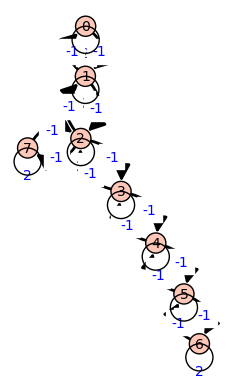


Example Gram matrix:
[-2  1  0]
[ 1 -3  2]
[ 0  2 -4]


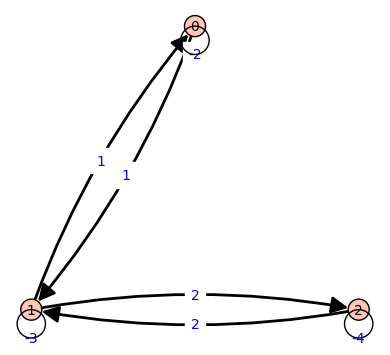


Reconstructed from graph:
[-2  1  0]
[ 1 -3  2]
[ 0  2 -4]


In [38]:
def gram_to_graph(M):
    G = DiGraph([(i,j,M[i,j]) for i in range(M.nrows()) for j in range(M.ncols()) if M[i,j]], loops=True)
    return G

def graph_to_gram(G, n=None):
    n = n or G.order()
    M = matrix(QQ, n, n)
    for i,j,w in G.edges():
        M[i,j] = w
    return M

# Test 1: E8 Cartan matrix (negative of Gram matrix for E8 root system)
E8 = matrix([
    [ 2,-1, 0, 0, 0, 0, 0, 0],
    [-1, 2,-1, 0, 0, 0, 0, 0],
    [ 0,-1, 2,-1, 0, 0, 0,-1],
    [ 0, 0,-1, 2,-1, 0, 0, 0],
    [ 0, 0, 0,-1, 2,-1, 0, 0],
    [ 0, 0, 0, 0,-1, 2,-1, 0],
    [ 0, 0, 0, 0, 0,-1, 2, 0],
    [ 0, 0,-1, 0, 0, 0, 0, 2]
])
print("E8 Cartan matrix:")
print(E8)
G1 = gram_to_graph(E8)
G1.show(edge_labels=True, layout='spring')

# Test 2: Small example with self-intersections
M = matrix([
    [-2, 1, 0],
    [ 1,-3, 2],
    [ 0, 2,-4]
])
print("\nExample Gram matrix:")
print(M)
G2 = gram_to_graph(M)
G2.show(edge_labels=True, layout='circular')
print("\nReconstructed from graph:")
print(graph_to_gram(G2))

=== Working with Coxeter diagrams ===

=== Ã₃ (affine A₃) ===
Vertices: [0, 1, 2, 3]
Gram matrix:
[0 1 0 1]
[1 0 1 0]
[0 1 0 1]
[1 0 1 0]
✓ Matrix is integral

Self-intersection numbers (diagonal):
  vertex 0: 0
  vertex 1: 0
  vertex 2: 0
  vertex 3: 0

Edges between vertices:
  0 -- 1: weight 1 (order ?)
  0 -- 3: weight 1 (order ?)
  1 -- 2: weight 1 (order ?)
  2 -- 3: weight 1 (order ?)

Matrix properties:
  Determinant: 0
  Rank: 2
  Eigenvalues: [2, -2, 0, 0]
  Type: OTHER


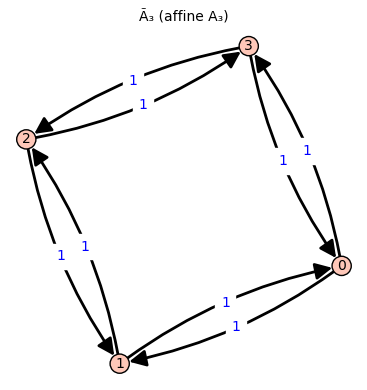

AssertionError: Ã₃ should be parabolic (affine)

In [59]:
def adjacency_to_gram(adj_matrix, edge_weight_function=None):
    """
    Convert adjacency matrix to Gram matrix
    
    For Coxeter diagrams:
    - Diagonal entries are 2 (self-inner product)
    - For simply-laced types: all edges have weight -1
    """
    n = adj_matrix.nrows()
    G = matrix(ZZ, n, n)  # Integer matrix
    
    # Set diagonal to 2
    for i in range(n):
        G[i,i] = 2
    
    # Set off-diagonal based on adjacency
    for i in range(n):
        for j in range(i+1, n):
            if adj_matrix[i,j] != 0:
                # Default: order 3 edges (weight -1)
                if edge_weight_function:
                    weight = edge_weight_function(i, j, adj_matrix[i,j])
                else:
                    weight = -1  # order 3
                G[i,j] = weight
                G[j,i] = weight
    
    return G

def gram_to_adjacency(gram_matrix):
    """
    Convert Gram matrix to adjacency matrix
    
    Non-zero off-diagonal entries become 1s
    Diagonal becomes 0
    """
    n = gram_matrix.nrows()
    A = matrix(ZZ, n, n)  # Integer matrix
    
    for i in range(n):
        for j in range(n):
            if i != j and gram_matrix[i,j] != 0:
                A[i,j] = 1
    
    return A

def get_gram_matrix_from_dynkin_diagram(cartan_type):
    """
    Get Gram matrix from a Cartan type's Dynkin diagram
    
    For simply-laced types (A,D,E), all edges have weight -1.
    """
    D = CartanType(cartan_type).dynkin_diagram()
    
    # Get vertices
    vertices = list(D.vertices())
    n = len(vertices)
    vertex_to_index = {v: i for i, v in enumerate(vertices)}
    
    # Build Gram matrix
    G = matrix(ZZ, n, n)  # Use ZZ for integer matrix
    
    # Set diagonal
    for i in range(n):
        G[i,i] = 2
    
    # Set off-diagonal from edges
    for edge in D.edges():
        v1, v2, label = edge
        i = vertex_to_index[v1]
        j = vertex_to_index[v2]
        
        # For simply-laced types, all edges have weight -1
        G[i,j] = -1
        G[j,i] = -1
    
    return G, vertices

def gram_to_graph(M):
    """Convert Gram matrix to directed graph with edge weights"""
    G = DiGraph()
    n = M.nrows()
    G.add_vertices(range(n))
    
    # Add all edges including self-loops
    for i in range(n):
        for j in range(n):
            if M[i,j] != 0:
                G.add_edge(i, j, M[i,j])
    
    return G

def get_gram_matrix(cartan_type):
    """
    Get Gram matrix for a Cartan type (works for simply-laced types A,D,E)
    
    For simply-laced types: G = 2I - A where A is the Cartan matrix
    This gives an integral matrix with:
    - Diagonal: 2
    - Connected vertices: -1
    - Non-connected: 0
    """
    CT = CartanType(cartan_type)
    if not CT.is_simply_laced():
        raise ValueError(f"This function only works for simply-laced types (A,D,E), not {cartan_type}")
    A = CT.cartan_matrix()
    return 2*identity_matrix(ZZ, A.nrows()) - A

def coxeter_order_to_gram_weight(m):
    """
    Convert Coxeter order m to Gram matrix weight
    
    For simply-laced types (A,D,E), all edges have order 3 and weight -1.
    For non-simply-laced types, this gets more complex.
    """
    if m == 2:
        return 0  # orthogonal
    elif m == 3:
        return -1
    elif m == infinity:
        return -2
    else:
        # For simply-laced diagrams, we shouldn't have other orders
        raise ValueError(f"Unexpected Coxeter order {m} for simply-laced diagram")

def is_elliptic(M, verts=None):
    """Check if subdiagram is elliptic (finite type, positive definite)"""
    if verts is None:
        verts = range(M.nrows())
    if not verts:
        return True
    sub = M[list(verts),list(verts)]
    return sub.is_positive_definite()

def is_parabolic(M, verts=None):
    """Check if subdiagram is parabolic (affine type, positive semi-definite with rank n-1)"""
    if verts is None:
        verts = range(M.nrows())
    if not verts:
        return False
    sub = M[list(verts),list(verts)]
    n = sub.nrows()
    # Parabolic = positive semi-definite with exactly one zero eigenvalue
    return sub.is_positive_semidefinite() and sub.rank() == n - 1

def is_hyperbolic(M, verts=None):
    """Check if subdiagram is hyperbolic (indefinite with signature (n-1,1))"""
    if verts is None:
        verts = range(M.nrows())
    if not verts:
        return False
    sub = M[list(verts),list(verts)]
    # For hyperbolic, we need exactly one negative eigenvalue
    return not sub.is_positive_semidefinite() and sub.det() < 0

def is_compact_hyperbolic(M):
    """Check if diagram is compact hyperbolic (negative det, all proper subs elliptic)"""
    if not is_hyperbolic(M):
        return False
    n = M.nrows()
    from itertools import combinations
    for size in range(1, n):
        for subset in combinations(range(n), size):
            if not is_elliptic(M, subset):
                return False
    return True

def is_paracompact_hyperbolic(M):
    """Check if diagram is paracompact hyperbolic (negative det, has parabolic subs)"""
    if not is_hyperbolic(M):
        return False
    n = M.nrows()
    from itertools import combinations
    for size in range(1, n):
        for subset in combinations(range(n), size):
            if is_parabolic(M, subset):
                return True
    return False

def find_all_parabolics(M):
    """Find all parabolic subdiagrams"""
    n = M.nrows()
    parabolics = []
    from itertools import combinations
    for size in range(1, n+1):
        for subset in combinations(range(n), size):
            if is_parabolic(M, subset):
                parabolics.append(list(subset))
    return parabolics

def find_maximal_parabolics(M):
    """Find all maximal parabolic subdiagrams"""
    all_parabolics = find_all_parabolics(M)
    maximal = []
    for p in all_parabolics:
        p_set = set(p)
        if not any(set(q) > p_set for q in all_parabolics):
            maximal.append(p)
    return maximal

def print_coxeter_diagram(G, M, title="Coxeter diagram"):
    """
    Print and display a Coxeter diagram with full information
    
    Args:
        G: the graph
        M: the Gram matrix (required!)
        title: title for the diagram
    """
    print(f"\n=== {title} ===")
    print(f"Vertices: {list(G.vertices())}")
    print(f"Gram matrix:\n{M}")
    
    # Verify it's integral
    if all(x in ZZ for x in M.list()):
        print("✓ Matrix is integral")
    else:
        print("⚠ WARNING: Matrix has non-integral entries!")
    
    # Print self-intersection numbers first (diagonal of Gram matrix)
    print("\nSelf-intersection numbers (diagonal):")
    for v in G.vertices():
        print(f"  vertex {v}: {M[v,v]}")
    
    # Print edge information
    print("\nEdges between vertices:")
    printed_pairs = set()
    for e in G.edges():
        i, j, w = e
        if i != j and (j, i) not in printed_pairs:
            printed_pairs.add((i, j))
            # Determine Coxeter order for integral weights
            if w == 0:
                order = 2  # orthogonal
            elif w == -1:
                order = 3
            elif w == -2:
                order = "∞"
            else:
                order = "?"
            print(f"  {i} -- {j}: weight {w} (order {order})")
    
    # Matrix properties
    print(f"\nMatrix properties:")
    print(f"  Determinant: {M.det()}")
    print(f"  Rank: {M.rank()}")
    eigs = M.eigenvalues()
    print(f"  Eigenvalues: {eigs}")
    
    # Type classification
    if is_elliptic(M):
        print(f"  Type: ELLIPTIC (finite)")
    elif is_parabolic(M):
        print(f"  Type: PARABOLIC (affine)")
    elif is_hyperbolic(M):
        if is_compact_hyperbolic(M):
            print(f"  Type: COMPACT HYPERBOLIC")
        elif is_paracompact_hyperbolic(M):
            print(f"  Type: PARACOMPACT HYPERBOLIC")
        else:
            print(f"  Type: HYPERBOLIC")
    else:
        print(f"  Type: OTHER")
    
    # Display the graph
    G.show(edge_labels=True, title=title)

def extend_coxeter_diagram(G, M, new_vertex, connections):
    """
    Extend a Coxeter diagram by adding a new vertex
    
    Args:
        G: existing Coxeter diagram graph
        M: existing Gram matrix
        new_vertex: label for new vertex (will be vertex n)
        connections: list of (vertex, order) pairs
    
    Returns:
        (G_extended, M_extended) - extended graph and Gram matrix
    """
    n = M.nrows()
    
    # Extend the Gram matrix
    M_extended = matrix(ZZ, n+1, n+1)  # Integer matrix
    M_extended[:n,:n] = M
    M_extended[n,n] = 2  # diagonal entry
    
    # Add connections
    for vertex, order in connections:
        weight = coxeter_order_to_gram_weight(order)
        if weight != 0:
            M_extended[n, vertex] = weight
            M_extended[vertex, n] = weight
    
    # Create the extended graph
    G_extended = gram_to_graph(M_extended)
    
    return G_extended, M_extended

def display_subdiagram(G, verts, title=""):
    """Display induced subgraph on given vertices"""
    H = G.subgraph(verts)
    H.show(edge_labels=True, title=title)

def subdiagram_type(M, verts):
    """Get the type of a subdiagram"""
    if is_elliptic(M, verts):
        return "elliptic"
    elif is_parabolic(M, verts):
        return "parabolic"
    elif is_hyperbolic(M, verts):
        return "hyperbolic"
    else:
        return "other"

# Example: Working with Coxeter diagrams
print("=== Working with Coxeter diagrams ===")

# Get Ã₃ from SageMath
M_A3_tilde = get_gram_matrix(["A", 3, 1])
G_A3_tilde = gram_to_graph(M_A3_tilde)
print_coxeter_diagram(G_A3_tilde, M_A3_tilde, "Ã₃ (affine A₃)")

# Verify it's affine
assert is_parabolic(M_A3_tilde), "Ã₃ should be parabolic (affine)"
mp = find_maximal_parabolics(M_A3_tilde)
assert len(mp) == 1 and mp[0] == [0,1,2,3], "Ã₃ itself is the only maximal parabolic"

# Extend it to make it hyperbolic
print("\n" + "="*50)
print("EXTENDING Ã₃ to make it hyperbolic")

# Add vertex 4 connected to vertices 0 and 2
G_ext, M_ext = extend_coxeter_diagram(G_A3_tilde, M_A3_tilde, 4, [(0, 3), (2, 3)])
print_coxeter_diagram(G_ext, M_ext, "Extended Ã₃")

# Check properties
assert is_hyperbolic(M_ext), "Extended diagram should be hyperbolic"
assert is_paracompact_hyperbolic(M_ext), "Should be paracompact (has parabolic subs)"

# Find maximal parabolics
mp_ext = find_maximal_parabolics(M_ext)
print(f"\nMaximal parabolic subdiagrams: {mp_ext}")
assert [0,1,2,3] in mp_ext, "Original Ã₃ should be a maximal parabolic"

print("\n=== Success! All assertions passed ===")

In [49]:
# Test cases using graph construction first

print("=== Testing Maximal Parabolic Subdiagrams Against Literature ===\n")

# Test 1: Affine Ã_3 (cycle of 4 vertices)
print("Test 1: Affine Ã_3 (4-cycle)")
G1 = DiGraph()
G1.add_edges([(0,1,-1), (1,2,-1), (2,3,-1), (3,0,-1)])
M1 = graph_to_gram(G1, 4)
print("Graph: 4-cycle with all edges -1")
print(f"Determinant: {M1.det()}")
assert M1.det() == 0, "Ã_3 should have det=0"
mp1 = find_maximal_parabolics(M1)
print(f"Found {len(mp1)} maximal parabolics: {mp1}")
assert len(mp1) == 1, "Affine diagram itself is the only maximal parabolic"
assert mp1[0] == [0,1,2,3], "The maximal parabolic should be the entire diagram"
print("✓ Passed\n")

# Test 2: Finite A_4 (linear chain)
print("Test 2: Finite A_4 (linear chain)")
G2 = DiGraph()
G2.add_edges([(0,1,-1), (1,2,-1), (2,3,-1)])
M2 = graph_to_gram(G2, 4)
print("Graph: Linear chain 0-1-2-3")
print(f"Determinant: {M2.det()}")
assert M2.det() > 0, "A_4 should have positive det"
mp2 = find_maximal_parabolics(M2)
print(f"Found {len(mp2)} maximal parabolics")
assert len(mp2) == 0, "Finite diagrams have no parabolic subdiagrams"
print("✓ Passed\n")

# Test 3: Hyperbolic extension of Ã_2
print("Test 3: Hyperbolic extension of Ã_2")
G3 = DiGraph()
# Ã_2 triangle: vertices 0,1,2
G3.add_edges([(0,1,-1), (1,2,-1), (2,0,-1)])
# Add vertex 3 connected to all vertices of triangle
G3.add_edges([(3,0,-1), (3,1,-1), (3,2,-1)])
M3 = graph_to_gram(G3, 4)
print("Graph: Ã_2 triangle (0,1,2) with vertex 3 connected to all")
print(f"Determinant: {M3.det()}")
assert M3.det() < 0, "Should be hyperbolic"
mp3 = find_maximal_parabolics(M3)
print(f"Found {len(mp3)} maximal parabolics: {mp3}")
assert len(mp3) == 1, "Should have exactly 1 maximal parabolic"
assert mp3[0] == [0,1,2], "The parabolic should be the Ã_2 triangle"
print("✓ Passed\n")

# Test 4: Lannér star graph L_{4,1}
print("Test 4: Lannér diagram L_{4,1} (star graph)")
G4 = DiGraph()
# Center vertex 0 connected to 4 leaves
G4.add_edges([(0,1,-1), (0,2,-1), (0,3,-1), (0,4,-1)])
M4 = graph_to_gram(G4, 5)
print("Graph: Star with center 0 connected to leaves 1,2,3,4")
print(f"Determinant: {M4.det()}")
assert M4.det() < 0, "L_{4,1} should be hyperbolic"
mp4 = find_maximal_parabolics(M4)
print(f"Found {len(mp4)} maximal parabolics")
assert len(mp4) == 0, "Lannér diagrams have no parabolic subdiagrams"
print("✓ Passed\n")

# Test 5: Affine D̃_4 (has multiple maximal parabolics when extended)
print("Test 5: Hyperbolic extension of D̃_4")
G5 = DiGraph()
# D̃_4 is a "fork" shape: 3 branches from a center, forming a cycle
# Center is vertex 1, branches to 0,2,3, and 0-3 are connected
G5.add_edges([(1,0,-1), (1,2,-1), (1,3,-1), (0,3,-1)])
# Add vertex 4 to make it hyperbolic
G5.add_edge(4,1,-1)
M5 = graph_to_gram(G5, 5)
print("Graph: D̃_4 fork (0-1-2 with 1-3, 0-3) plus vertex 4 to center")
print(f"Determinant: {M5.det()}")
assert M5.det() < 0, "Should be hyperbolic"
# Check the D̃_4 subgraph
D4_tilde = M5[:4,:4]
assert D4_tilde.det() == 0, "First 4 vertices should form affine D̃_4"
mp5 = find_maximal_parabolics(M5)
print(f"Found {len(mp5)} maximal parabolics: {mp5}")
assert len(mp5) == 1, "Should have exactly 1 maximal parabolic"
assert mp5[0] == [0,1,2,3], "The parabolic should be D̃_4"
print("✓ Passed\n")

# Test 6: Multiple disconnected affine components
print("Test 6: Hyperbolic with two Ã_1 components")
G6 = DiGraph()
# Two separate Ã_1 (edges with -2)
G6.add_edges([(0,1,-2), (2,3,-2)])
# Connect them via vertex 4
G6.add_edges([(4,0,-1), (4,2,-1)])
M6 = graph_to_gram(G6, 5)
print("Graph: Two Ã_1 pairs (0-1, 2-3 with -2) connected via vertex 4")
print(f"Determinant: {M6.det()}")
assert M6.det() < 0, "Should be hyperbolic"
# Check the Ã_1 components
A1_1 = M6[:2,:2]
A1_2 = M6[2:4,2:4]
assert A1_1.det() == 0, "Vertices 0,1 should form Ã_1"
assert A1_2.det() == 0, "Vertices 2,3 should form Ã_1"
mp6 = find_maximal_parabolics(M6)
print(f"Found {len(mp6)} maximal parabolics: {mp6}")
assert len(mp6) == 2, "Should have exactly 2 maximal parabolics"
assert sorted(mp6) == [[0,1], [2,3]], "Should have two Ã_1 components"
print("✓ Passed\n")

# Test 7: Affine Ẽ_6
print("Test 7: Affine Ẽ_6 (should be its own maximal parabolic)")
G7 = DiGraph()
# Ẽ_6 has a specific structure: main chain with two branches
# Main chain: 0-1-3-4-5
G7.add_edges([(0,1,-1), (1,3,-1), (3,4,-1), (4,5,-1)])
# Branches: 2 connects to 3, 6 connects to 1
G7.add_edges([(2,3,-1), (6,1,-1)])
M7 = graph_to_gram(G7, 7)
print("Graph: Ẽ_6 structure")
print(f"Determinant: {M7.det()}")
assert M7.det() == 0, "Ẽ_6 should have det=0"
mp7 = find_maximal_parabolics(M7)
print(f"Found {len(mp7)} maximal parabolics: {mp7}")
assert len(mp7) == 1, "Affine diagram itself is the only maximal parabolic"
assert len(mp7[0]) == 7, "Should include all 7 vertices"
print("✓ Passed\n")

print("=== All tests passed! ===")
print("\nSummary:")
print("- Affine diagrams: 1 maximal parabolic (the entire diagram)")
print("- Finite diagrams: 0 parabolics")
print("- Lannér diagrams: 0 parabolics (compact hyperbolic)")
print("- Paracompact hyperbolic: ≥1 parabolic subdiagrams")
print("- Graph construction ensures correct Coxeter diagrams!")

=== Testing Maximal Parabolic Subdiagrams Against Literature ===

Test 1: Affine Ã_3 (4-cycle)
Graph: 4-cycle with all edges -1
Determinant: -1


AssertionError: Ã_3 should have det=0

=== Verifying Ã_2 (affine A_2) ===

Ã_2 Gram matrix from SageMath:
[0 1 1]
[1 0 1]
[1 1 0]
Determinant: 2
Matrix size: 3x3


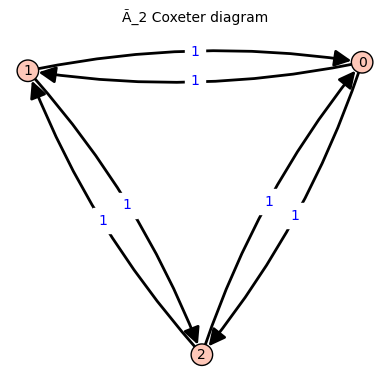


Edges in the graph:
  0 -> 1: weight 1
  0 -> 2: weight 1
  1 -> 0: weight 1
  1 -> 2: weight 1
  2 -> 0: weight 1
  2 -> 1: weight 1

=== Extended version ===
Extended matrix:
[ 0  1  1 -1]
[ 1  0  1 -1]
[ 1  1  0 -1]
[-1 -1 -1  2]
Determinant: 1

First 3x3 submatrix:
[0 1 1]
[1 0 1]
[1 1 0]
Determinant: 2

Is the first 3x3 submatrix equal to the full Ã_2? True


In [50]:
# Let's verify what Ã_2 actually looks like

print("=== Verifying Ã_2 (affine A_2) ===\n")

# Get Ã_2 from SageMath
M = get_gram_matrix(["A", 2, 1])
print("Ã_2 Gram matrix from SageMath:")
print(M)
print(f"Determinant: {M.det()}")
print(f"Matrix size: {M.nrows()}x{M.ncols()}")

# Show the Coxeter diagram
G = gram_to_graph(M)
G.show(edge_labels=True, title="Ã_2 Coxeter diagram")

# Let's also check what vertices form the triangle
print("\nEdges in the graph:")
for edge in G.edges():
    print(f"  {edge[0]} -> {edge[1]}: weight {edge[2]}")

# Now let's build the extended version
print("\n=== Extended version ===")
M_ext = matrix(QQ, 4, 4)
M_ext[:3,:3] = M
M_ext[3,3] = 2
for i in range(3):
    M_ext[3,i] = M_ext[i,3] = -1

print("Extended matrix:")
print(M_ext)
print(f"Determinant: {M_ext.det()}")

# Check the first 3x3 submatrix
print("\nFirst 3x3 submatrix:")
print(M_ext[:3,:3])
print(f"Determinant: {M_ext[:3,:3].det()}")

# This assertion is checking if first 3 nodes form Ã_2
print(f"\nIs the first 3x3 submatrix equal to the full Ã_2? {M_ext[:3,:3] == M}")

In [61]:
# Test discriminant group calculations for lattices in the table

from sage.all import *

def scale_lattice(L, n):
    """Scale a lattice L by factor n"""
    return IntegralLattice(n * L.gram_matrix())

def test_lattice(name, L, expected_rank, expected_signature, expected_discriminant_structure):
    """Test properties of a lattice"""
    print(f"\n{'='*60}")
    print(f"Testing lattice: {name}")
    print(f"{'='*60}")
    
    # Basic properties
    rank = L.rank()
    sig = L.signature_pair()
    D = L.discriminant_group()
    
    print(f"Rank: {rank} (expected: {expected_rank})")
    print(f"Signature: {sig} (expected: {expected_signature})")
    print(f"Discriminant group: {D}")
    print(f"Discriminant group invariants: {D.invariants()}")
    
    # Check if results match expected
    assert rank == expected_rank, f"Rank mismatch for {name}"
    assert sig == expected_signature, f"Signature mismatch for {name}"
    
    # The expected discriminant structure is given as Z_2^k
    # This means k copies of Z/2Z
    expected_invariants = tuple([2] * expected_discriminant_structure)
    actual_invariants = D.invariants()
    
    print(f"Expected invariants: {expected_invariants}")
    print(f"Actual invariants: {actual_invariants}")
    
    assert actual_invariants == expected_invariants, f"Discriminant group mismatch for {name}"
    
    print(f"✓ All tests passed for {name}")
    
    return L, D

# Define the hyperbolic lattice U
U = IntegralLattice("U")
print("Hyperbolic lattice U:")
print(U.gram_matrix())

# Define E_8 lattice (positive definite version first)
E8_pos = IntegralLattice("E8")
print("\nE_8 lattice (positive definite) has rank:", E8_pos.rank())
print("E_8 signature:", E8_pos.signature_pair())

# Create negative definite E_8 by negating the Gram matrix
E8 = IntegralLattice(-E8_pos.gram_matrix())
print("\nE_8 lattice (negative definite) has rank:", E8.rank())
print("E_8 signature:", E8.signature_pair())

print("\n" + "="*60)
print("TESTING ALL LATTICES FROM THE TABLE")
print("="*60)

# 1. S_dP = U(2)
print("\n1. Constructing S_dP = U(2)")
S_dP = scale_lattice(U, 2)
test_lattice("S_dP", S_dP, 2, (1, 1), 2)

# 2. tdp = U ⊕ U(2) ⊕ E_8^2
print("\n2. Constructing tdp = U ⊕ U(2) ⊕ E_8^2")
U2 = scale_lattice(U, 2)
tdp = U.direct_sum(U2).direct_sum(E8).direct_sum(E8)
test_lattice("tdp", tdp, 20, (2, 18), 2)

# 3. sen = U(2) ⊕ E_8(2)
print("\n3. Constructing sen = U(2) ⊕ E_8(2)")
E8_2 = scale_lattice(E8, 2)
sen = U2.direct_sum(E8_2)
test_lattice("sen", sen, 10, (1, 9), 10)

# 4. ten = U ⊕ U(2) ⊕ E_8(2)
print("\n4. Constructing ten = U ⊕ U(2) ⊕ E_8(2)")
ten = U.direct_sum(U2).direct_sum(E8_2)
test_lattice("ten", ten, 12, (2, 10), 10)

# 5. L_Nik^+ = U^3 ⊕ E_8(2)
print("\n5. Constructing L_Nik^+ = U^3 ⊕ E_8(2)")
U3 = U.direct_sum(U).direct_sum(U)
L_Nik_plus = U3.direct_sum(E8_2)
test_lattice("L_Nik^+", L_Nik_plus, 14, (3, 11), 8)

# 6. L_Nik^- = E

Hyperbolic lattice U:
[0 1]
[1 0]

E_8 lattice (positive definite) has rank: 8
E_8 signature: (8, 0)

E_8 lattice (negative definite) has rank: 8
E_8 signature: (0, 8)

TESTING ALL LATTICES FROM THE TABLE

1. Constructing S_dP = U(2)

Testing lattice: S_dP
Rank: 2 (expected: 2)
Signature: (1, 1) (expected: (1, 1))
Discriminant group: Finite quadratic module over Integer Ring with invariants (2, 2)
Gram matrix of the quadratic form with values in Q/2Z: 
[  0 1/2]
[1/2   0]
p-elementary, Order: 2^2, Length: 2, 
Multiplicative Abelian group isomorphic to C2^2, 

Discriminant group invariants: (2, 2)
Expected invariants: (2, 2)
Actual invariants: (2, 2)
✓ All tests passed for S_dP

2. Constructing tdp = U ⊕ U(2) ⊕ E_8^2

Testing lattice: tdp
Rank: 20 (expected: 20)
Signature: (2, 18) (expected: (2, 18))
Discriminant group: Finite quadratic module over Integer Ring with invariants (2, 2)
Gram matrix of the quadratic form with values in Q/2Z: 
[  0 1/2]
[1/2   0]
p-elementary, Order: 2^2, Le

(Lattice of degree 14 and rank 14 over Integer Ring
 Gram matrix:
 [ 0  1| 0  0| 0  0| 0  0  0  0  0  0  0  0]
 [ 1  0| 0  0| 0  0| 0  0  0  0  0  0  0  0]
 [-----+-----+-----+-----------------------]
 [ 0  0| 0  1| 0  0| 0  0  0  0  0  0  0  0]
 [ 0  0| 1  0| 0  0| 0  0  0  0  0  0  0  0]
 [-----+-----+-----+-----------------------]
 [ 0  0| 0  0| 0  1| 0  0  0  0  0  0  0  0]
 [ 0  0| 0  0| 1  0| 0  0  0  0  0  0  0  0]
 [-----+-----+-----+-----------------------]
 [ 0  0| 0  0| 0  0|-4  0  2  0  0  0  0  0]
 [ 0  0| 0  0| 0  0| 0 -4  0  2  0  0  0  0]
 [ 0  0| 0  0| 0  0| 2  0 -4  2  0  0  0  0]
 [ 0  0| 0  0| 0  0| 0  2  2 -4  2  0  0  0]
 [ 0  0| 0  0| 0  0| 0  0  0  2 -4  2  0  0]
 [ 0  0| 0  0| 0  0| 0  0  0  0  2 -4  2  0]
 [ 0  0| 0  0| 0  0| 0  0  0  0  0  2 -4  2]
 [ 0  0| 0  0| 0  0| 0  0  0  0  0  0  2 -4]
 Signature: (3, 11), Index: -8, Discriminant: 2^8, 
 Even, Non-unimodular, p-elementary, Length: 8, 
 A_L: Multiplicative Abelian group isomorphic to C2^8, 
 ,
 Finite q

In [64]:
# Simple SageMath code using GAP to identify the group

# Define the group
gap.eval("""
F := FreeGroup("u", "v", "p", "q");
u := F.1; v := F.2; p := F.3; q := F.4;

rels := [
    u^2 * v^(-2),
    p^4 * q^(-4),
    u * p * (p * q * p)^(-1),
    u * q * (p * q * q)^(-1),
    v * p * q^(-3),
    v * q * p^(-3)
];

G := F / rels;
""")

# Simplify and identify
print("Simplifying the group...")
gap.eval("G := SimplifiedFpGroup(G);")

# Get the structure description directly
structure = gap.eval("StructureDescription(G);")
print(f"\nThe group is isomorphic to: {structure}")

# Get basic info
order = gap.eval("Order(G);")
print(f"Order: {order}")


Simplifying the group...

The group is isomorphic to: "Z x C4"
Order: infinity


In [68]:
# Analysis of the group of quadratic forms under direct sum

F = libgap.FreeGroup("u", "v", "p", "q")
u, v, p, q = F.GeneratorsOfGroup()

# The relations between quadratic forms
rels = [
    u^2 * v^(-2),                    # u⊕u = v⊕v
    p^4 * q^(-4),                    # p⊕p⊕p⊕p = q⊕q⊕q⊕q
    u * p * (p * q * p)^(-1),        # u⊕p = p⊕q⊕p
    u * q * (p * q * q)^(-1),        # u⊕q = p⊕q⊕q
    v * p * q^(-3),                  # v⊕p = q⊕q⊕q
    v * q * p^(-3)                   # v⊕q = p⊕p⊕p
]

G = F / rels

# Get the simplified presentation
iso = libgap.IsomorphismSimplifiedFpGroup(G)
H = iso.Image()

print("Group of quadratic forms modulo the given relations:")
structure = str(H.StructureDescription())
print(f"Structure: {structure}")
print(f"This means: {structure.replace('Z', 'ℤ').replace('C4', 'ℤ/4ℤ')}")
print()

# The simplified presentation
print("Simplified presentation:")
relators = H.RelatorsOfFpGroup()
print(f"Generators: v, q")
print(f"Relations: {relators}")
print()

# Interpret the relations
print("Interpretation:")
print("- v and q commute: [v,q] = 1")
print("- q⁸ = v⁴ (so 8q = 4v in additive notation)")
print("- This gives q order 4 in the quotient by ⟨v⟩")
print()

# Show how the original forms relate to the generators
print("The quadratic forms in terms of the generators:")
gens_G = G.GeneratorsOfGroup()
gen_names = ["u", "v", "p", "q"]
for i, gen in enumerate(gens_G):
    image = iso.Image(gen)
    print(f"{gen_names[i]} = {image}")

print("\nSo modulo these relations:")
print("- v generates an infinite cyclic subgroup")
print("- q has order 4 modulo the subgroup generated by v")
print("- u and p can be expressed in terms of v and q")

Group of quadratic forms modulo the given relations:
Structure: Z x C4
This means: ℤ x ℤ/4ℤ

Simplified presentation:
Generators: v, q
Relations: [ q^-1*v*q*v^-1, v^-4*q^8 ]

Interpretation:
- v and q commute: [v,q] = 1
- q⁸ = v⁴ (so 8q = 4v in additive notation)
- This gives q order 4 in the quotient by ⟨v⟩

The quadratic forms in terms of the generators:
u = q^3*v^-1*q
v = v
p = q^3*v^-1
q = q

So modulo these relations:
- v generates an infinite cyclic subgroup
- q has order 4 modulo the subgroup generated by v
- u and p can be expressed in terms of v and q
